In [1]:
# ============================================================
# TIME SERIES SECTION — Online Retail Dataset
# ============================================================

# --- 0. Load libraries ---
# All packages must be installed before loading
if (!require("readxl"))    install.packages("readxl")
if (!require("dplyr"))     install.packages("dplyr")
if (!require("lubridate")) install.packages("lubridate")
if (!require("ggplot2"))   install.packages("ggplot2")
if (!require("forecast"))  install.packages("forecast")
if (!require("tseries"))   install.packages("tseries")
if (!require("TTR"))       install.packages("TTR")
if (!require("Metrics"))   install.packages("Metrics")

library(readxl); library(dplyr); library(lubridate)
library(ggplot2); library(forecast); library(tseries)
library(TTR); library(Metrics)
# --- 1. Load data ---
# Adjust path to your actual raw file location
retail <- read_excel("Online Retail.xlsx")

# --- 2. Clean for time series use ---
retail_clean <- retail %>%
  filter(!is.na(CustomerID),           # remove rows with no customer
         Quantity > 0,                  # remove cancellations/returns
         UnitPrice > 0) %>%             # remove zero-price rows
  mutate(
    InvoiceDate = as.Date(InvoiceDate), # ensure Date type
    Revenue = Quantity * UnitPrice,     # compute line revenue
    YearMonth = floor_date(InvoiceDate, 'month') # round down to month
  )

# --- 3. Aggregate to monthly revenue ---
monthly_revenue <- retail_clean %>%
  group_by(YearMonth) %>%
  summarise(TotalRevenue = sum(Revenue), .groups = 'drop') %>%
  arrange(YearMonth)

# Inspect the series
print(monthly_revenue)
cat('Number of monthly observations:', nrow(monthly_revenue), '\n')
# --- 4. Convert to ts object ---
# Start: December 2010 (month 12), frequency=12 for monthly
ts_revenue <- ts(
  monthly_revenue$TotalRevenue,
  start = c(2010, 12),
  frequency = 12
)

# Quick summary
summary(ts_revenue)
cat('Time series class:', class(ts_revenue), '\n')


Loading required package: readxl

Loading required package: dplyr


Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union


Loading required package: lubridate


Attaching package: ‘lubridate’


The following objects are masked from ‘package:base’:

    date, intersect, setdiff, union


Loading required package: ggplot2

Loading required package: forecast

Warning message in library(package, lib.loc = lib.loc, character.only = TRUE, logical.return = TRUE, :
“there is no package called ‘forecast’”
Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependencies ‘colorspace’, ‘fracdiff’, ‘lmtest’, ‘timeDate’, ‘urca’, ‘zoo’, ‘RcppArmadillo’


Loading required package: tseries

Warning message in library(package, lib.loc = lib.loc, character.only = TRUE, logical.return = TRUE, :
“there is no packag

# A tibble: 13 × 2
   YearMonth  TotalRevenue
   <date>            <dbl>
 1 2010-12-01      572714.
 2 2011-01-01      569445.
 3 2011-02-01      447137.
 4 2011-03-01      595501.
 5 2011-04-01      469200.
 6 2011-05-01      678595.
 7 2011-06-01      661214.
 8 2011-07-01      600091.
 9 2011-08-01      645344.
10 2011-09-01      952838.
11 2011-10-01     1039319.
12 2011-11-01     1161817.
13 2011-12-01      518193.
Number of monthly observations: 13 


   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
 447137  569445  600091  685493  678595 1161817 

Time series class: ts 


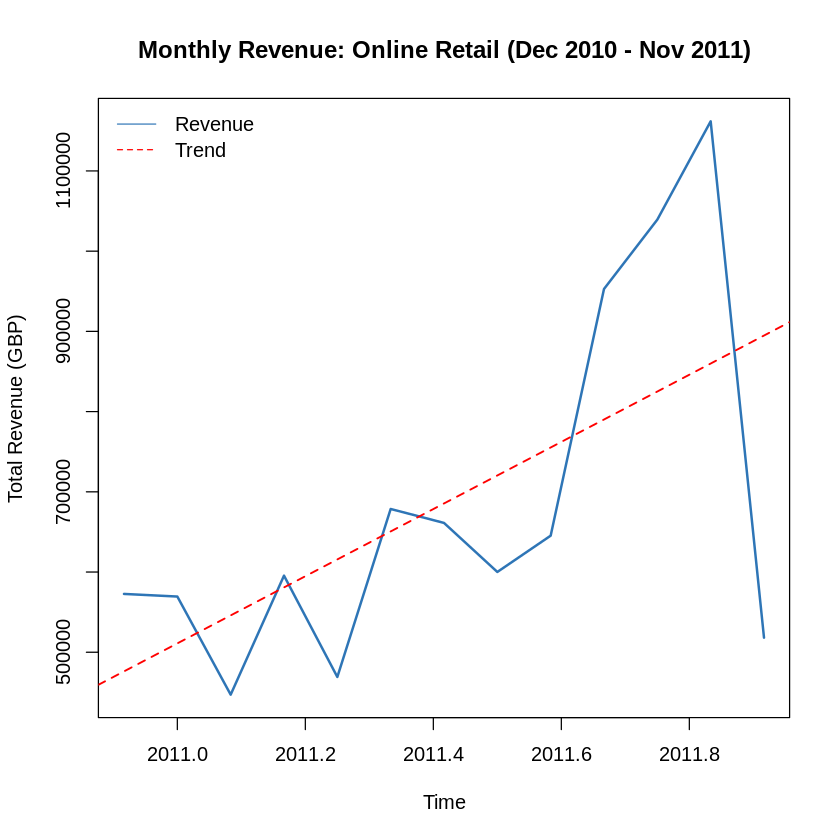

`geom_smooth()` using formula = 'y ~ x'


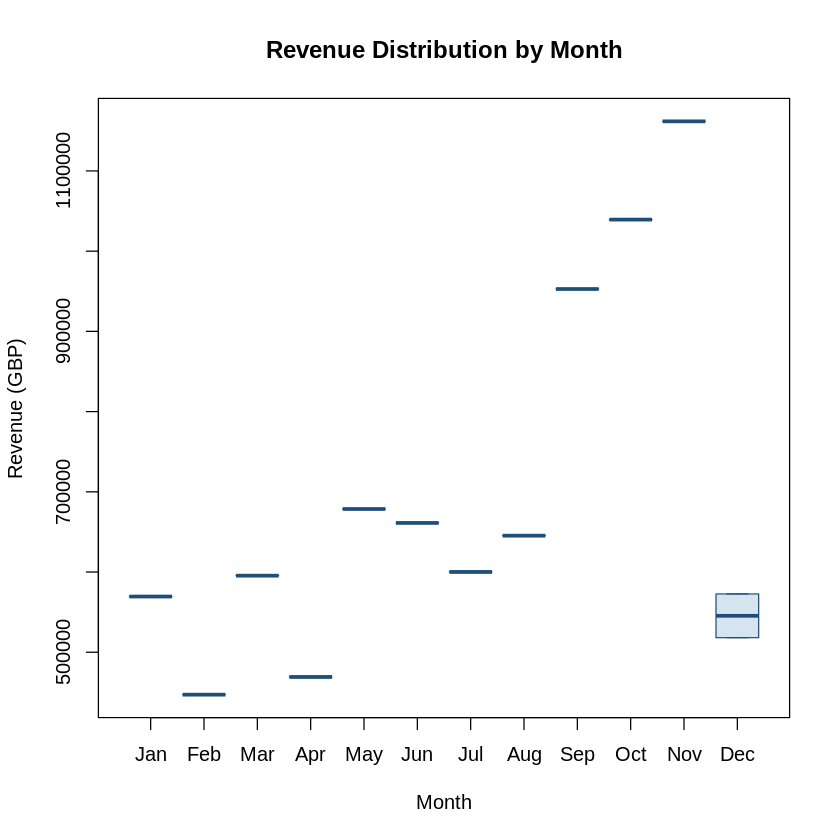

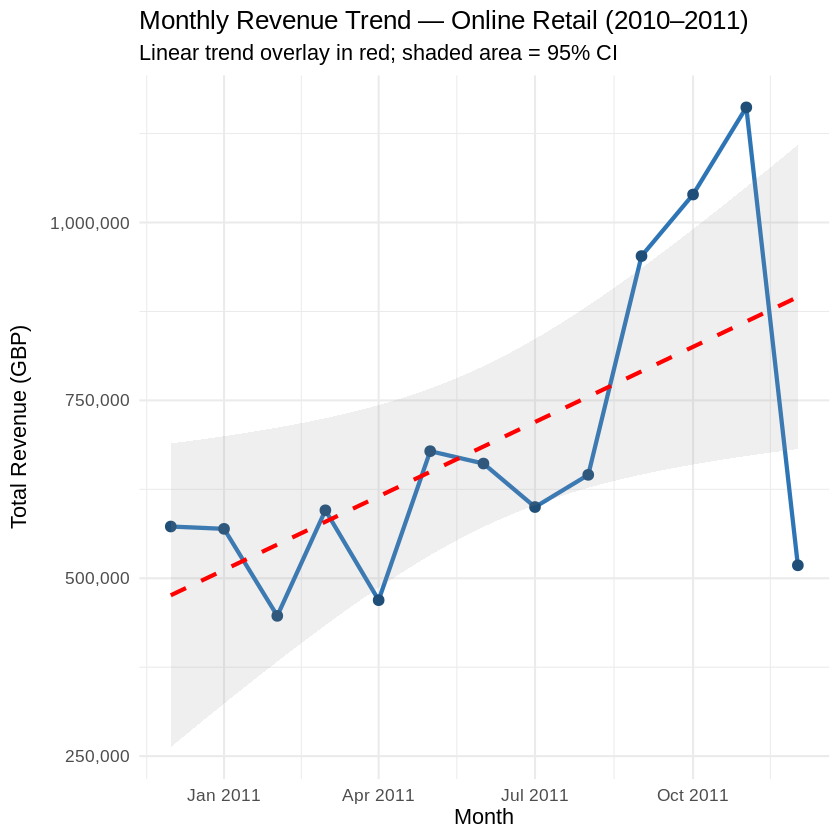

In [2]:
# --- 5. Raw time series plot ---
plot(ts_revenue,
     main = 'Monthly Revenue: Online Retail (Dec 2010 - Nov 2011)',
     xlab = 'Time', ylab = 'Total Revenue (GBP)',
     col = '#2E75B6', lwd = 2)
abline(reg = lm(ts_revenue ~ time(ts_revenue)),
       col = 'red', lty = 2, lwd = 1.5)  # trend line
legend('topleft', legend = c('Revenue', 'Trend'), col = c('#2E75B6','red'),
       lty = c(1,2), bty = 'n')
# --- 6. Monthly boxplot (seasonal check) ---
boxplot(ts_revenue ~ cycle(ts_revenue),
        names = month.abb,
        main  = 'Revenue Distribution by Month',
        xlab  = 'Month', ylab = 'Revenue (GBP)',
        col   = '#D6E4F0', border = '#1F4E79')
# --- 8. ggplot2 version for report (cleaner) ---
df_plot <- data.frame(
  Date    = as.Date(time(ts_revenue) %>% {as.Date(paste0(floor(.), '-',
                     round((. %% 1)*12+1), '-01'))}),
  Revenue = as.numeric(ts_revenue)
)

# Simpler approach using monthly_revenue directly:
ggplot(monthly_revenue, aes(x = YearMonth, y = TotalRevenue)) +
  geom_line(colour = '#2E75B6', linewidth = 1.2) +
  geom_point(colour = '#1F4E79', size = 2.5) +
  geom_smooth(method = 'lm', se = TRUE, colour = 'red',
              linetype = 'dashed', alpha = 0.15) +
  scale_y_continuous(labels = scales::comma) +
  labs(
    title    = 'Monthly Revenue Trend — Online Retail (2010–2011)',
    subtitle = 'Linear trend overlay in red; shaded area = 95% CI',
    x = 'Month', y = 'Total Revenue (GBP)'
  ) +
  theme_minimal(base_size = 13)


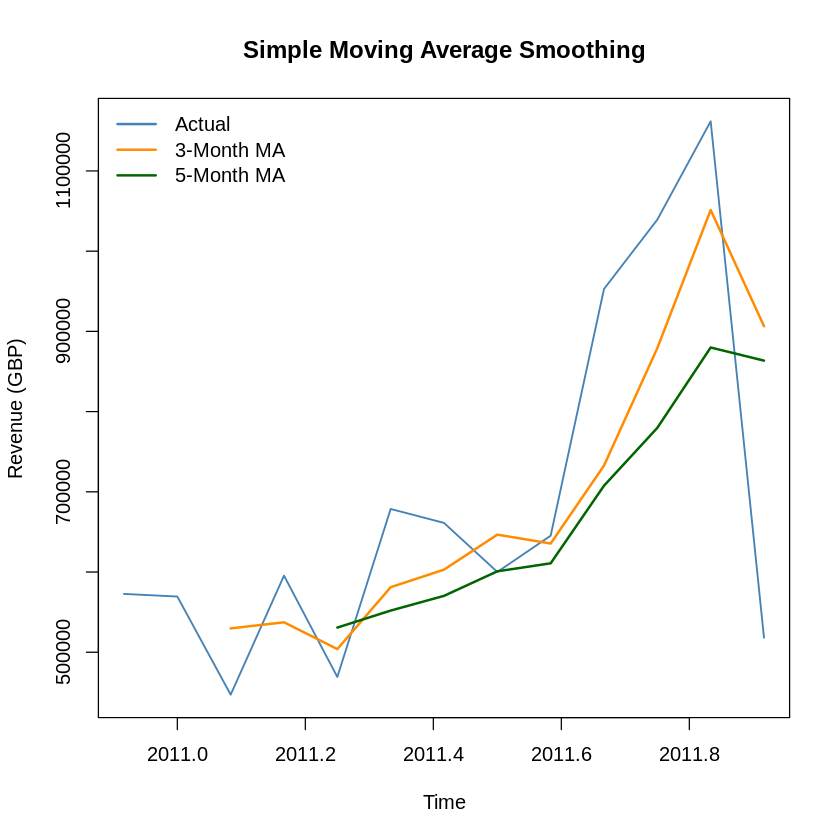

In [3]:
# ============================================================
# SMOOTHING METHODS
# ============================================================

# --- 9. Simple Moving Averages (3-month and 5-month) ---
sma3 <- SMA(ts_revenue, n = 3)   # 3-month moving average
sma5 <- SMA(ts_revenue, n = 5)   # 5-month moving average

# Plot original + smoothed versions
ts.plot(ts_revenue, sma3, sma5,
        col   = c('steelblue', 'darkorange', 'darkgreen'),
        lwd   = c(1.5, 2, 2),
        lty   = c(1, 1, 1),
        main  = 'Simple Moving Average Smoothing',
        xlab  = 'Time', ylab = 'Revenue (GBP)')
legend('topleft',
       legend = c('Actual', '3-Month MA', '5-Month MA'),
       col    = c('steelblue','darkorange','darkgreen'),
       lty    = 1, lwd = 2, bty = 'n')



Forecast method: Simple exponential smoothing

Model Information:
Simple exponential smoothing 

Call:
ses(y = ts_revenue, h = 3)

  Smoothing parameters:
    alpha = 0.3864 

  Initial states:
    l = 560932.7565 

  sigma:  224591.9

     AIC     AICc      BIC 
357.5457 360.2123 359.2405 

Error measures:
                   ME     RMSE      MAE       MPE     MAPE    MASE        ACF1
Training set 47616.37 206594.5 150883.8 0.8415642 21.53808 2.76744 -0.02344278

Forecasts:
         Point Forecast    Lo 80   Hi 80    Lo 95   Hi 95
Jan 2012       800111.2 512285.1 1087937 359919.2 1240303
Feb 2012       800111.2 491546.8 1108676 328202.6 1272020
Mar 2012       800111.2 472117.1 1128105 298487.4 1301735

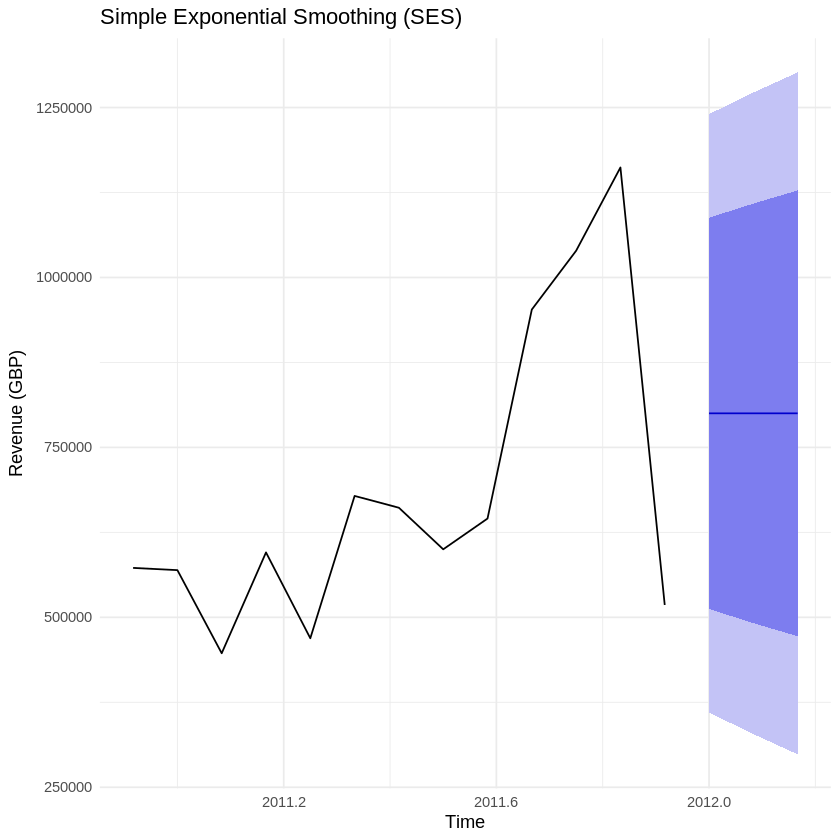

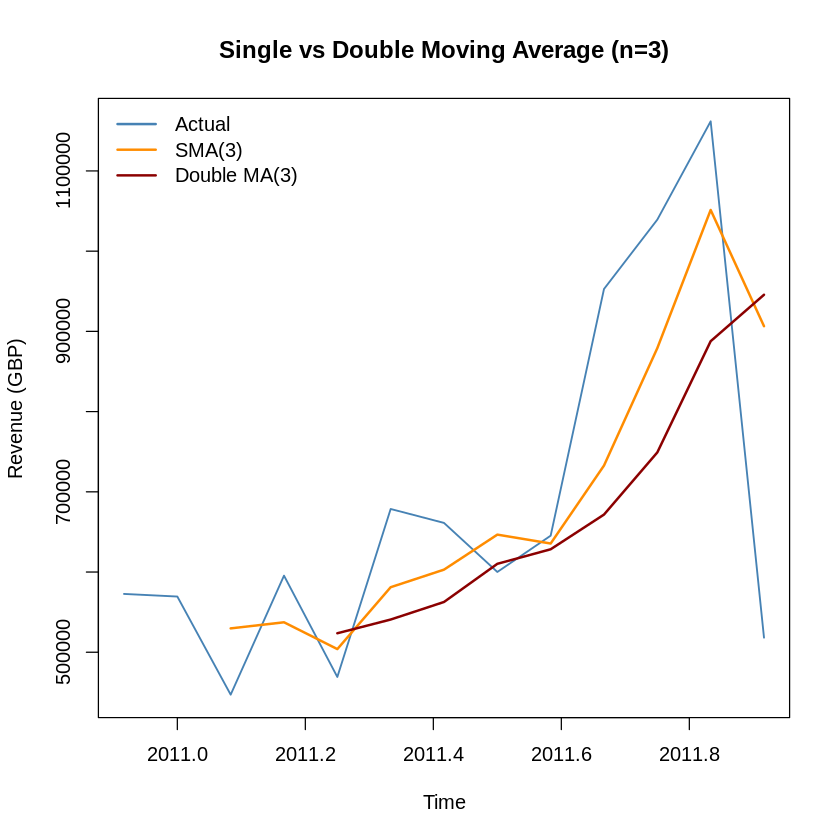

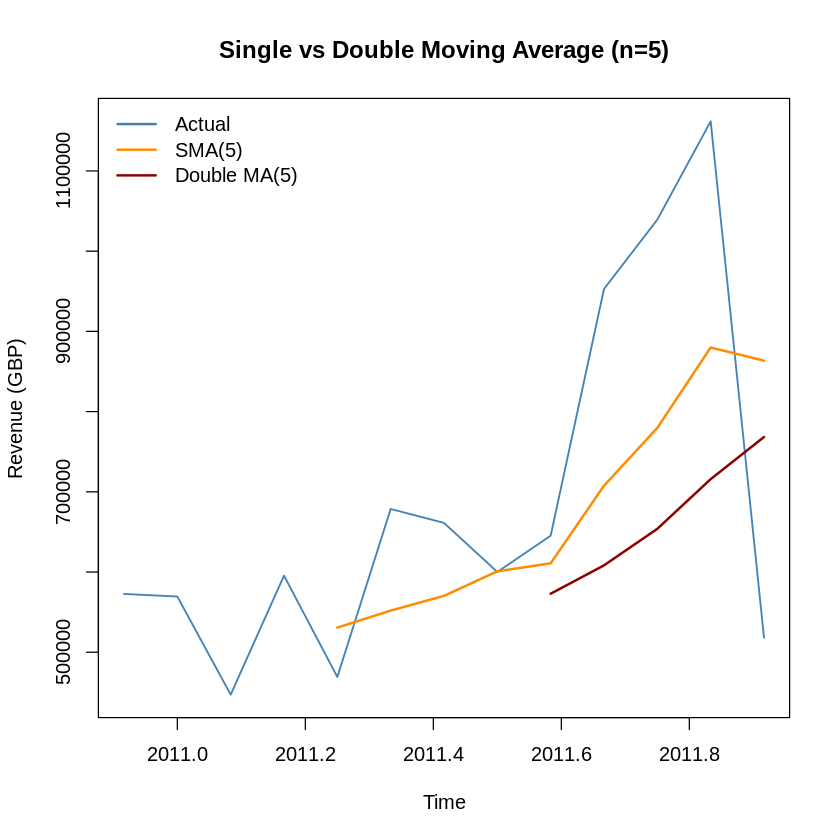

In [4]:
# --- 10. SES ---
ses_fit <- ses(ts_revenue, h = 3)
summary(ses_fit)
autoplot(ses_fit) +
  labs(title = 'Simple Exponential Smoothing (SES)',
       x = 'Time', y = 'Revenue (GBP)') +
  theme_minimal()

# Double Moving Average on ts_revenue
sma3       <- SMA(ts_revenue, n = 3)
double_ma3 <- SMA(sma3, n = 3)

sma5       <- SMA(ts_revenue, n = 5)
double_ma5 <- SMA(sma5, n = 5)

# Plot SMA vs DMA (order 3)
ts.plot(ts_revenue, sma3, double_ma3,
        col  = c('steelblue', 'darkorange', 'darkred'),
        lwd  = c(1.5, 2, 2),
        main = 'Single vs Double Moving Average (n=3)',
        xlab = 'Time', ylab = 'Revenue (GBP)')
legend('topleft',
       legend = c('Actual', 'SMA(3)', 'Double MA(3)'),
       col    = c('steelblue', 'darkorange', 'darkred'),
       lty = 1, lwd = 2, bty = 'n')

# Plot SMA vs DMA (order 5)
ts.plot(ts_revenue, sma5, double_ma5,
        col  = c('steelblue', 'darkorange', 'darkred'),
        lwd  = c(1.5, 2, 2),
        main = 'Single vs Double Moving Average (n=5)',
        xlab = 'Time', ylab = 'Revenue (GBP)')
legend('topleft',
       legend = c('Actual', 'SMA(5)', 'Double MA(5)'),
       col    = c('steelblue', 'darkorange', 'darkred'),
       lty = 1, lwd = 2, bty = 'n')

In [5]:
# ============================================================
# STATIONARITY TESTING
# ============================================================

# --- 13. Augmented Dickey-Fuller Test ---
# H0: series has a unit root (non-stationary)
# H1: series is stationary
# If p-value < 0.05: reject H0 → stationary
adf_result <- adf.test(ts_revenue, alternative = 'stationary')
print(adf_result)

# --- 14. KPSS Test (complementary) ---
# H0: series is stationary
# If p-value < 0.05: reject H0 → non-stationary
kpss_result <- kpss.test(ts_revenue)
print(kpss_result)

# Decision logic (write this as a comment in your report):
# ADF: p-value < 0.05 AND KPSS: p-value > 0.05 → STATIONARY
# Otherwise → apply log transformation and/or differencing
# --- 15. Log transformation (reduces variance, common for revenue) ---
ts_log <- log(ts_revenue)

# --- 16. First differencing (removes trend → stationarity) ---
ts_diff <- diff(ts_log)

# Re-test after transformation
adf_after <- adf.test(ts_diff, alternative = 'stationary')
cat('ADF after log+diff: p-value =', adf_after$p.value, '\n')
# If p < 0.05: we have achieved stationarity with d=1



	Augmented Dickey-Fuller Test

data:  ts_revenue
Dickey-Fuller = -2.8986, Lag order = 2, p-value = 0.2301
alternative hypothesis: stationary


	KPSS Test for Level Stationarity

data:  ts_revenue
KPSS Level = 0.34779, Truncation lag parameter = 2, p-value = 0.09966

ADF after log+diff: p-value = 0.7963266 


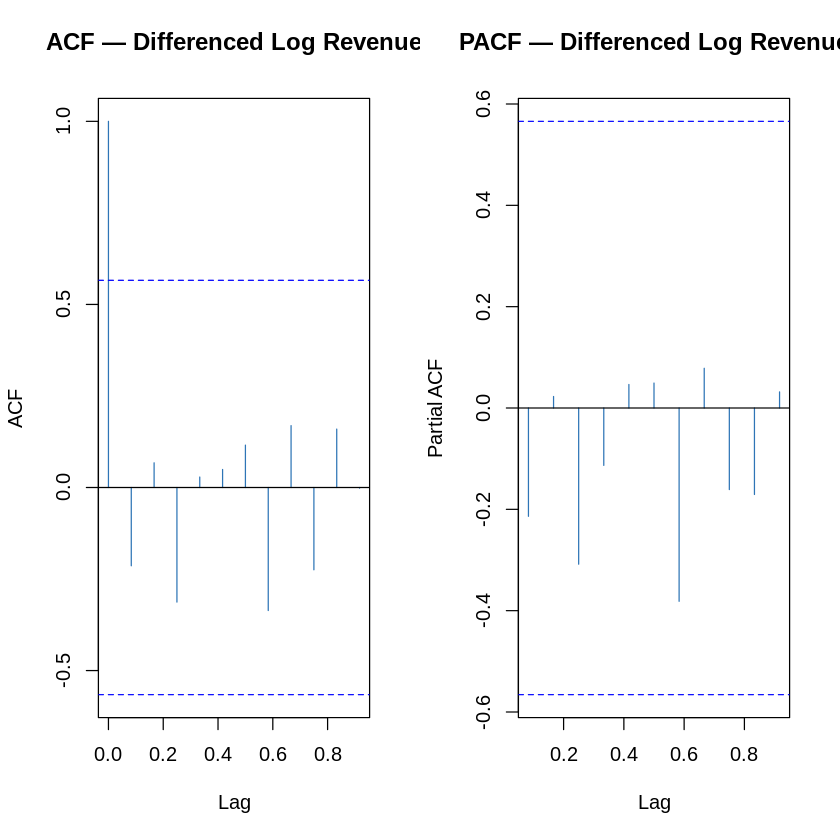

In [6]:
# ============================================================
# ACF AND PACF PLOTS
# ============================================================

# --- 17. ACF and PACF on differenced log series ---
par(mfrow = c(1, 2))  # side-by-side

acf(ts_diff,
    main  = 'ACF — Differenced Log Revenue',
    lag.max = 12,
    col   = '#2E75B6')

pacf(ts_diff,
     main  = 'PACF — Differenced Log Revenue',
     lag.max = 12,
     col   = '#2E75B6')

par(mfrow = c(1, 1))  # reset

# Reading the plots:
# ACF: significant spikes at lag k → MA(q) parameter = k
# PACF: significant spikes at lag k → AR(p) parameter = k
# Spike = bar that crosses the dashed blue confidence band



 ARIMA(0,1,0)                               : 8.546625
 ARIMA(0,1,0)            with drift         : 11.47142
 ARIMA(0,1,1)                               : 9.822395
 ARIMA(0,1,1)            with drift         : Inf
 ARIMA(0,1,2)                               : 13.38622
 ARIMA(0,1,2)            with drift         : Inf
 ARIMA(0,1,3)                               : Inf
 ARIMA(0,1,3)            with drift         : Inf
 ARIMA(0,1,4)                               : Inf
 ARIMA(0,1,4)            with drift         : Inf
 ARIMA(1,1,0)                               : 10.3378
 ARIMA(1,1,0)            with drift         : 13.9647
 ARIMA(1,1,1)                               : Inf
 ARIMA(1,1,1)            with drift         : Inf
 ARIMA(1,1,2)                               : Inf
 ARIMA(1,1,2)            with drift         : Inf
 ARIMA(1,1,3)                               : Inf
 ARIMA(1,1,3)            with drift         : Inf
 ARIMA(1,1,4)                    : Inf
 ARIMA(1,1,4)            with dr

Series: ts_log 
ARIMA(0,1,0) 

sigma^2 = 0.09773:  log likelihood = -3.07
AIC=8.15   AICc=8.55   BIC=8.63

Training set error measures:
                       ME      RMSE      MAE         MPE     MAPE     MASE
Training set -0.006675445 0.3003594 0.211206 -0.07570505 1.583642 2.111238
                   ACF1
Training set -0.2147768

Selected model: ARIMA( 0 , 1 , 0 )
AIC: 8.146625 
BIC: 8.631531 


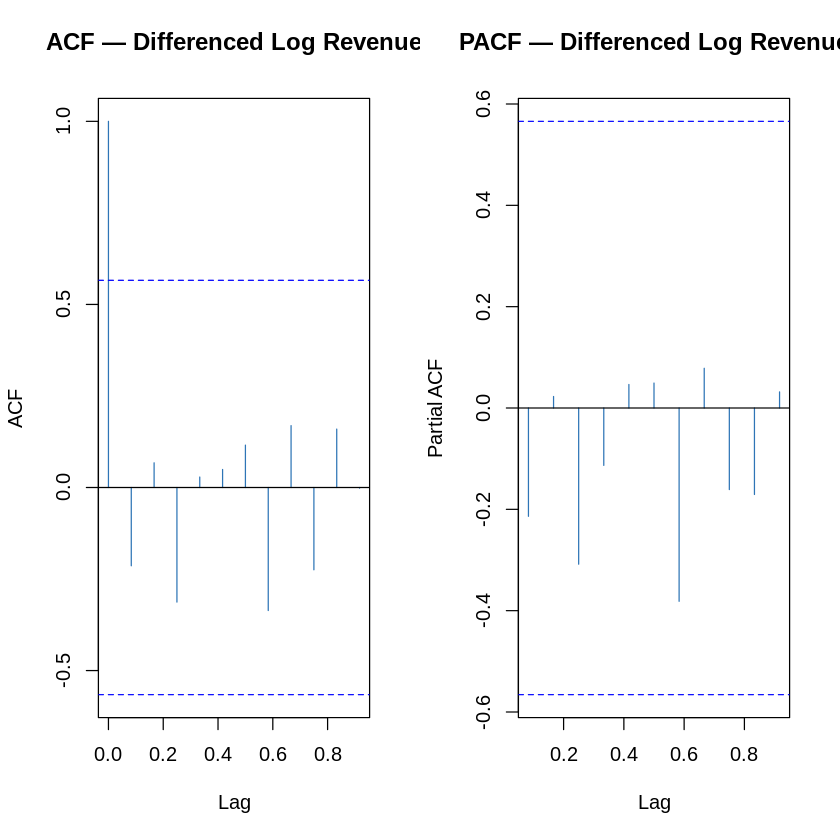

Ljung-Box p-value: 0.2861976 
PASS: residuals are white noise 


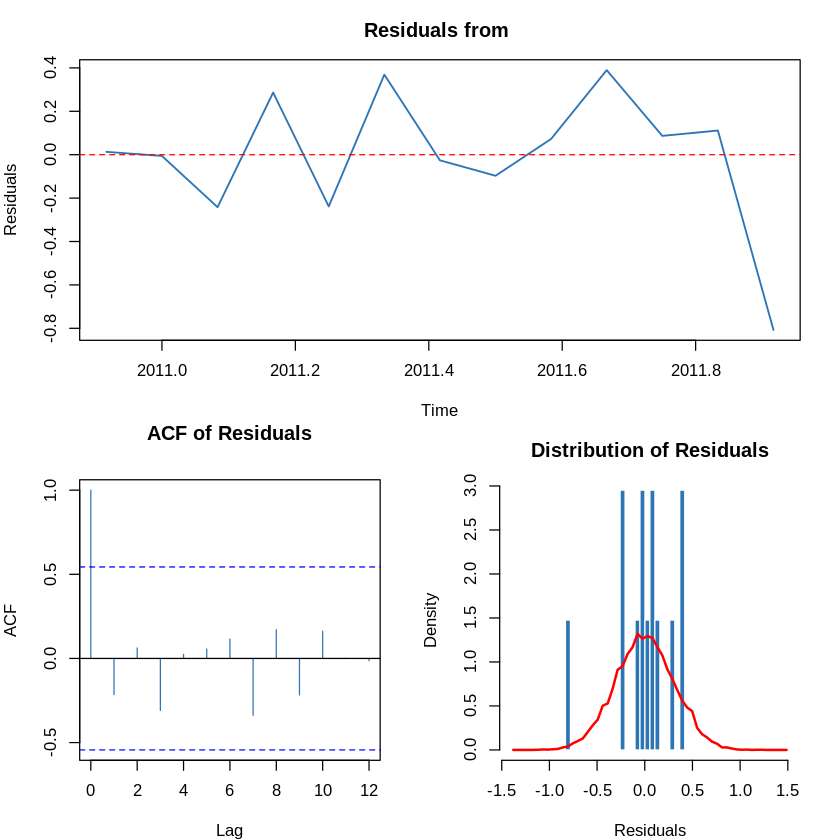

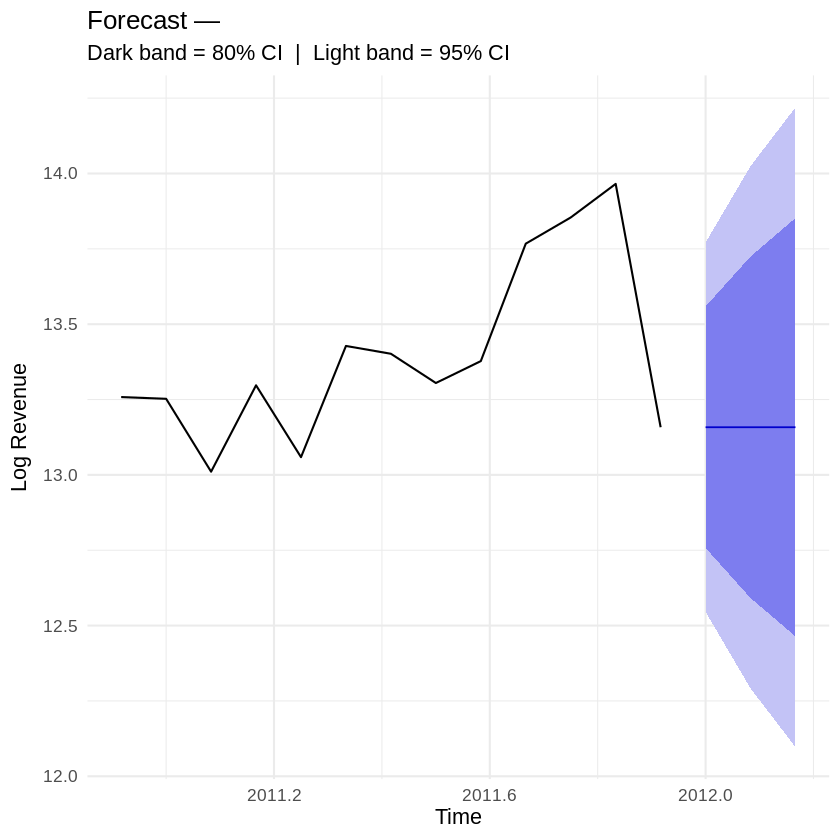

In [13]:
# ============================================================
# ARIMA — COMPLETE IMPLEMENTATION
# ============================================================

# --- Step 1: Prepare series ---
ts_log   <- log(ts_revenue)
ts_diff1 <- diff(ts_log)

# --- Step 2: Model selection ---
arima_auto <- auto.arima(
  ts_log,
  stepwise      = FALSE,
  approximation = FALSE,
  trace         = TRUE    # prints all models tried
)
summary(arima_auto)
cat("Selected model: ARIMA(",
    arima_auto$arma[1], ",",
    arima_auto$arma[6], ",",
    arima_auto$arma[2], ")\n")
cat("AIC:", AIC(arima_auto), "\n")
cat("BIC:", BIC(arima_auto), "\n")

# --- Step 3: ACF / PACF ---
par(mfrow = c(1, 2))
acf(ts_diff1,
    main    = "ACF — Differenced Log Revenue",
    lag.max = 12,
    col     = "#2E75B6")
pacf(ts_diff1,
     main    = "PACF — Differenced Log Revenue",
     lag.max = 12,
     col     = "#2E75B6")
par(mfrow = c(1, 1))

# --- Step 4: Residual diagnostics (3-panel) ---
res    <- as.numeric(residuals(arima_auto))
mysd   <- sd(res)
mynorm <- rnorm(10000, 0, mysd)
mybins <- seq(min(res, mynorm) - mysd,
              max(res, mynorm) + mysd,
              IQR(res) / 4)

layout(matrix(c(1, 1, 2, 3), nrow = 2, byrow = TRUE))
par(mar = c(4, 4, 3, 2))

plot(residuals(arima_auto),
     main = paste("Residuals from", arima_auto$method),
     ylab = "Residuals", xlab = "Time",
     col  = "#2E75B6", lwd = 1.5, type = "l")
abline(h = 0, col = "red", lty = 2)

acf(res,
    main    = "ACF of Residuals",
    lag.max = 20,
    col     = "#2E75B6")

hist(res,
     col    = "#2E75B6", freq = FALSE,
     breaks = mybins, border = "white",
     main   = "Distribution of Residuals",
     xlab   = "Residuals")
myhist <- hist(mynorm, plot = FALSE, breaks = mybins)
points(myhist$mids, myhist$density,
       type = "l", col = "red", lwd = 2)

layout(1)
par(mar = c(5, 4, 4, 2))  # reset

# Ljung-Box test
lb <- Box.test(residuals(arima_auto), lag = 10, type = "Ljung-Box")
cat("Ljung-Box p-value:", lb$p.value, "\n")
cat(ifelse(lb$p.value > 0.05,
    "PASS: residuals are white noise",
    "FAIL: residuals show autocorrelation"), "\n")

# --- Step 5: Forecast with confidence intervals ---
final_fc <- forecast(arima_auto, h = 3)

autoplot(final_fc) +
  labs(title    = paste("Forecast —", arima_auto$method),
       subtitle = "Dark band = 80% CI  |  Light band = 95% CI",
       x = "Time", y = "Log Revenue") +
  theme_minimal(base_size = 13)


Call:
arima(x = ts_log, order = c(0, 1, 1))

Coefficients:
          ma1
      -0.5622
s.e.   0.2850

sigma^2 estimated as 0.08246:  log likelihood = -2.24,  aic = 8.49

Training set error measures:
                     ME      RMSE       MAE       MPE     MAPE     MASE
Training set 0.04899258 0.2759175 0.2112715 0.3334678 1.570904 2.111893
                    ACF1
Training set -0.06566739

Manual ARIMA AIC: 8.489062 
Manual ARIMA BIC: 9.458875 

 ARIMA(0,1,0)                               : 8.546625
 ARIMA(0,1,0)            with drift         : 11.47142
 ARIMA(0,1,1)                               : 9.822395
 ARIMA(0,1,1)            with drift         : Inf
 ARIMA(0,1,2)                               : 13.38622
 ARIMA(0,1,2)            with drift         : Inf
 ARIMA(0,1,3)                               : Inf
 ARIMA(0,1,3)            with drift         : Inf
 ARIMA(0,1,4)                               : Inf
 ARIMA(0,1,4)            with drift         : Inf
 ARIMA(1,1,0)                               : 10.3378
 ARIMA(1,1,0)            with drift         : 13.9647
 ARIMA(1,1,1)                               : Inf
 ARIMA(1,1,1)            with drift         : Inf
 ARIMA(1,1,2)                               : Inf
 ARIMA(1,1,2)            with drift         : Inf
 ARIMA(1,1,3)                               : Inf
 ARIMA(1,1,3)            with drift         : Inf
 ARIMA(1,1,4)  

Series: ts_log 
ARIMA(0,1,0) 

sigma^2 = 0.09773:  log likelihood = -3.07
AIC=8.15   AICc=8.55   BIC=8.63

Training set error measures:
                       ME      RMSE      MAE         MPE     MAPE     MASE
Training set -0.006675445 0.3003594 0.211206 -0.07570505 1.583642 2.111238
                   ACF1
Training set -0.2147768

Auto ARIMA order: ARIMA( 0 , 1 , 0 )
Auto ARIMA AIC: 8.146625 
Auto ARIMA BIC: 8.631531 

	Ljung-Box test

data:  Residuals from ARIMA(0,1,0)
Q* = 2.6742, df = 3, p-value = 0.4446

Model df: 0.   Total lags used: 3


	Box-Ljung test

data:  residuals(arima_auto)
X-squared = 11.983, df = 10, p-value = 0.2862

Ljung-Box p-value: 0.2861976 
PASS: residuals are white noise 


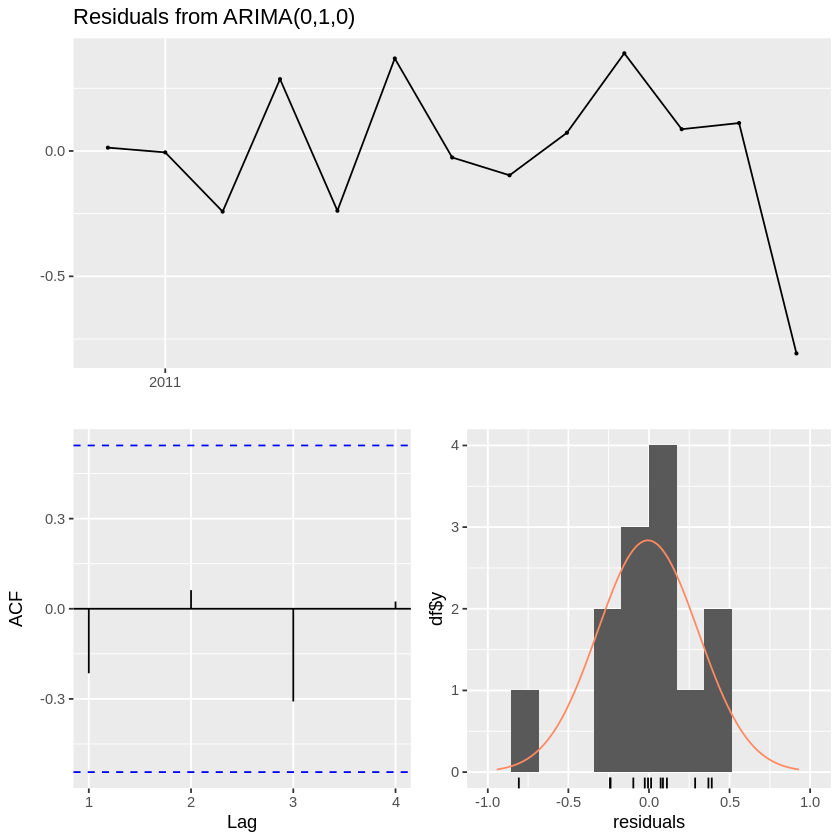

In [7]:
# ============================================================
# ARIMA MODEL FITTING
# ============================================================

# --- 18. Manual ARIMA (based on ACF/PACF reading) ---
# Example: ARIMA(0,1,1) — adjust p,d,q based on YOUR ACF/PACF results
# d=1 because one differencing made it stationary
# p=0 from PACF (no significant lags beyond 1)
# q=1 from ACF (significant lag at 1)
arima_manual <- arima(
  ts_log,
  order = c(0, 1, 1)   # <-- update p,q based on your plots
)
summary(arima_manual)
cat('Manual ARIMA AIC:', AIC(arima_manual), '\n')
cat('Manual ARIMA BIC:', BIC(arima_manual), '\n')
# --- 19. auto.arima (automated selection) ---
# Uses information criteria (AIC) to select best order automatically
arima_auto <- auto.arima(
  ts_log,
  stepwise    = FALSE,  # exhaustive search (slower but thorough)
  approximation = FALSE,
  trace       = TRUE    # print all models tried
)
summary(arima_auto)
cat('Auto ARIMA order: ARIMA(',
    arima_auto$arma[1], ',',
    arima_auto$arma[6], ',',
    arima_auto$arma[2], ')\n')
cat('Auto ARIMA AIC:', AIC(arima_auto), '\n')
cat('Auto ARIMA BIC:', BIC(arima_auto), '\n')
# --- 20. Residual diagnostics (CRITICAL — must check!) ---
# Good model: residuals should look like white noise
checkresiduals(arima_auto)  # plots ACF of residuals + histogram

# Ljung-Box test: H0 = residuals are independent (white noise)
# p > 0.05 = good (residuals have no remaining autocorrelation)
lb_test <- Box.test(residuals(arima_auto), lag = 10, type = 'Ljung-Box')
print(lb_test)
cat('Ljung-Box p-value:', lb_test$p.value, '\n')
cat(ifelse(lb_test$p.value > 0.05, 'PASS: residuals are white noise',
           'FAIL: residuals show remaining autocorrelation'), '\n')


In [14]:
# --- 22. Fit models on training set and forecast ---
ts_log_train <- log(ts_train)

# ARIMA forecast
fit_arima_train <- auto.arima(ts_log_train, stepwise = FALSE)
fc_arima        <- forecast(fit_arima_train, h = n_test)
fc_arima_rev    <- exp(as.numeric(fc_arima$mean))

# SES forecast
fit_ses_train <- ses(ts_train, h = n_test)

# Naive forecast (benchmark)
fc_naive <- naive(ts_train, h = n_test)

# --- 23. Compute evaluation metrics ---
eval_metrics <- function(actual, predicted, model_name) {
  rmse_val <- rmse(actual, predicted)
  mae_val  <- mae(actual, predicted)
  mape_val <- mean(abs((actual - predicted) / actual)) * 100
  cat(sprintf('%-20s RMSE: %10.2f  MAE: %10.2f  MAPE: %.2f%%\n',
              model_name, rmse_val, mae_val, mape_val))
  return(c(Model = model_name,
           RMSE  = round(rmse_val, 2),
           MAE   = round(mae_val,  2),
           MAPE  = round(mape_val, 2)))
}

actual <- as.numeric(ts_test)

cat('=== MODEL EVALUATION ON TEST SET ===\n')
r1 <- eval_metrics(actual, fc_arima_rev,                   'ARIMA (auto)')
r2 <- eval_metrics(actual, as.numeric(fit_ses_train$mean), 'SES')
r3 <- eval_metrics(actual, as.numeric(fc_naive$mean),      'Naive Baseline')

results_df <- as.data.frame(rbind(r1, r2, r3))
rownames(results_df) <- NULL
print(results_df)

=== MODEL EVALUATION ON TEST SET ===
ARIMA (auto)         RMSE:  378535.48  MAE:  321812.29  MAPE: 55.55%
SES                  RMSE:  370800.27  MAE:  321812.29  MAPE: 54.75%
Naive Baseline       RMSE:  378535.48  MAE:  321812.29  MAPE: 55.55%
           Model      RMSE       MAE  MAPE
1   ARIMA (auto) 378535.48 321812.29 55.55
2            SES 370800.27 321812.29 54.75
3 Naive Baseline 378535.48 321812.29 55.55


=== ADF: First Differencing ===

	Augmented Dickey-Fuller Test

data:  ts_diff1
Dickey-Fuller = -1.4121, Lag order = 2, p-value = 0.7963
alternative hypothesis: stationary


=== ADF: Second Differencing ===

	Augmented Dickey-Fuller Test

data:  ts_diff2
Dickey-Fuller = -0.90663, Lag order = 2, p-value = 0.9343
alternative hypothesis: stationary



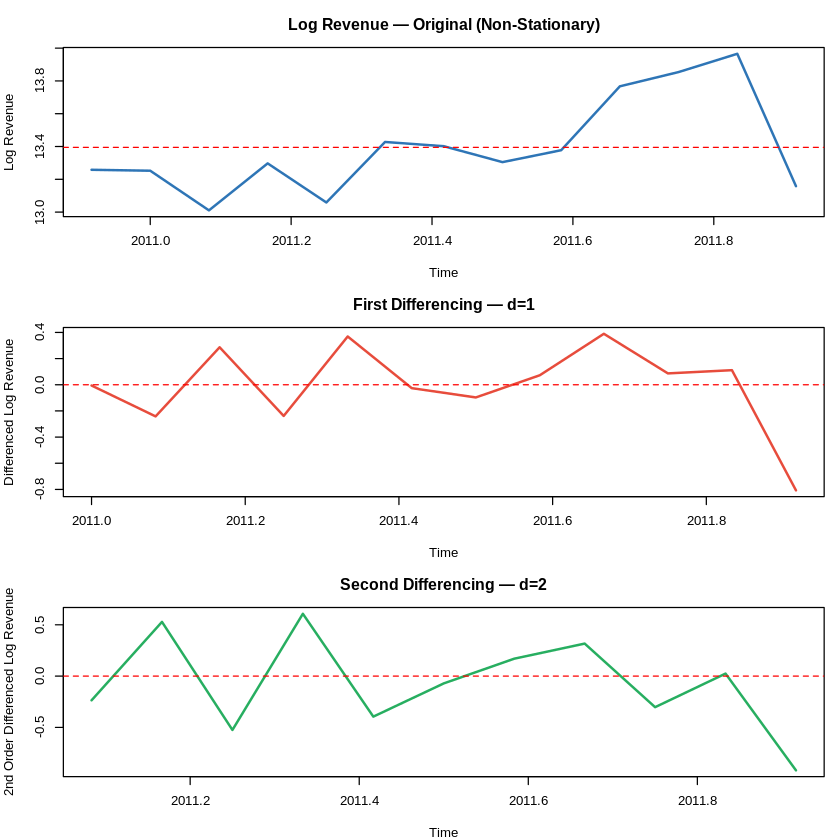

In [9]:
# --- Original, 1st and 2nd order differencing ---
ts_log   <- log(ts_revenue)
ts_diff1 <- diff(ts_log)
ts_diff2 <- diff(ts_log, differences = 2)

par(mfrow = c(3, 1), mar = c(4, 4, 3, 1))

plot(ts_log,
     main = "Log Revenue — Original (Non-Stationary)",
     xlab = "Time", ylab = "Log Revenue",
     col  = "#2E75B6", lwd  = 2)
abline(h = mean(ts_log), col = "red", lty = 2)

plot(ts_diff1,
     main = "First Differencing — d=1",
     xlab = "Time", ylab = "Differenced Log Revenue",
     col  = "#E74C3C", lwd  = 2)
abline(h = 0, col = "red", lty = 2)

plot(ts_diff2,
     main = "Second Differencing — d=2",
     xlab = "Time", ylab = "2nd Order Differenced Log Revenue",
     col  = "#27AE60", lwd  = 2)
abline(h = 0, col = "red", lty = 2)

par(mfrow = c(1, 1))

# ADF test on both to compare
cat("=== ADF: First Differencing ===\n")
print(adf.test(ts_diff1, alternative = "stationary"))

cat("\n=== ADF: Second Differencing ===\n")
print(adf.test(ts_diff2, alternative = "stationary"))